## The `reset` parameter in ReservoirPy

This tutorial explains what the `reset` method does on a ReservoirPy node and why it matters when you run a trained Echo State Network (ESN) on new data.

Every node in ReservoirPy keeps an internal state, a vector that carries the memory of the inputs it has seen. When you train an ESN, the reservoir state at the end of training holds information about the training sequence. If you then run the same ESN on a test sequence without touching that state, the first predictions are influenced by the leftover training state. Calling `reset()` zeroes the state so the network starts each run from a clean slate.

The difference is easiest to see on a forecasting task. We train an ESN on the Mackey-Glass time series, then predict the next 500 steps twice, once with the training state intact and once after a `reset()`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from reservoirpy.nodes import Reservoir, Ridge
from reservoirpy.datasets import mackey_glass

X = mackey_glass(n_timesteps=2000, tau=17, seed=42).reshape(-1, 1)
train, test = X[:1500], X[1500:2000]

res = Reservoir(100, lr=0.5, input_scaling=0.5, seed=42)
readout = Ridge(ridge=1e-6)
esn = res >> readout
esn.fit(train, train)

# run without touching the state
pred_no_reset = esn.run(test)

# zero the reservoir state, then run again
res.reset()
pred_reset = esn.run(test)

mse_no_reset = float(np.mean((pred_no_reset - test) ** 2))
mse_reset = float(np.mean((pred_reset - test) ** 2))
print(f"MSE without reset: {mse_no_reset:.3e}")
print(f"MSE with reset   : {mse_reset:.3e}")


MSE without reset: 1.659e-08
MSE with reset   : 3.778e-06


The two runs give very different errors. Without a reset the reservoir carries its training state into the test run, so the first predictions are already close to the target and the mean squared error is tiny. After a `reset()` the state starts at zero, the network needs a few timesteps to warm up, and the transient pushes the error up.

The plot below zooms into the first 60 timesteps of the test sequence. The no-reset prediction tracks the target from the first step. The reset prediction starts slightly off and converges within a few steps.


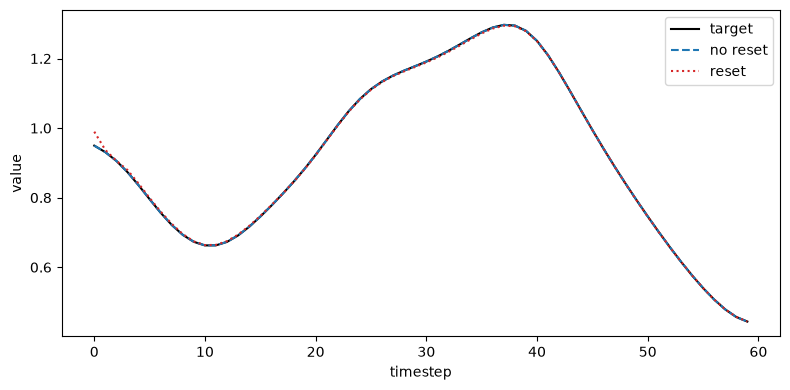

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(test[:60], label="target", color="black", lw=1.5)
ax.plot(pred_no_reset[:60], label="no reset", color="tab:blue", ls="--")
ax.plot(pred_reset[:60], label="reset", color="tab:red", ls=":")
ax.set_xlabel("timestep")
ax.set_ylabel("value")
ax.legend()
fig.tight_layout()
plt.show()


## When to use `reset`

Use `reset()` when you want each run to be independent of what came before, for example when you evaluate a model on several separate sequences or when you compare runs that should start from the same initial condition. Skip it when the training state is a useful prior, such as when the test sequence continues directly from the training sequence.

The `reset` method lives on every node and returns the previous state, so you can inspect or restore it if needed. See the [node documentation](https://reservoirpy.readthedocs.io/en/latest/user_guide/node.html) for the full API.
